# I. Tiền xử lý NLP cho Tweet (Airline Sentiment)

Dataset: [twitter-airline-sentiment](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) - phân tích cảm xúc tweet về các hãng hàng không Mỹ (2015).

Pipeline:
1. **RegEx**: gỡ `@mention`, `#hashtag`, URL, emoji (và một số biểu tượng dạng text).
2. **Chuẩn hóa**: giải mã HTML entity, chữ thường.
3. **Stop words** tiếng Anh + **Lemmatization** (WordNet).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import html
from pathlib import Path

from collections import Counter

import nltk
import pandas as pd
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [4]:
# nltk.download()

In [5]:
DATA_PATH = "data/Tweets.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### Download packages NLTK

In [6]:
def _ensure_nltk(pkg: str) -> None:
    try:
        if pkg == "stopwords":
            nltk.data.find("corpora/stopwords")
        elif pkg == "wordnet":
            nltk.data.find("corpora/wordnet")
        elif pkg in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{pkg}")
        else:
            nltk.data.find(f"taggers/{pkg}")
    except LookupError:
        nltk.download(pkg)


for _p in ("punkt_tab", "punkt", "stopwords", "wordnet", "averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
    _ensure_nltk(_p)

try:
    word_tokenize("ping")
except LookupError:
    nltk.download("punkt")
    nltk.download("punkt_tab")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lucian\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [7]:
STOP = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

In [8]:
CSV_PATH = "data/Tweets.csv"

df = pd.read_csv(CSV_PATH, encoding="utf-8")
print(df.shape)
print(df.columns)
df[["airline_sentiment", "airline", "text"]]

(14640, 15)
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')


,airline_sentiment,airline,text
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...
...,...,...,...
14635,positive,American,@AmericanAir thank you we got on a different f...
14636,negative,American,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,American,@AmericanAir Please bring American Airlines to...
14638,negative,American,"@AmericanAir you have my money, you change my ..."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

## 2. Làm sạch bằng Regular Expression

- **URL**: `http(s)://...`, `www....`, rút gọn `t.co/...`
- **@mention**: `@handle`
- **#hashtag**: `#tag`
- **Emoji**: các khối Unicode phổ biến + emoticon kiểu `:-)` `:D`

Sau đó **html.unescape** để xử lý `&amp;`, `&lt;`, v.v.

In [10]:
# Regex
RE_URL = re.compile(
    r"https?://\S+|www\.\S+", re.IGNORECASE
)
RE_MENTION = re.compile(r"@\w+")
RE_HASHTAG = re.compile(r"#\w+")

# Emoji => lấy theo dải mã Unicode
RE_EMOJI = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"  # Supplemental
    "\U0001F900-\U0001F9FF"  # supplemental symbols
    "\U0001FA70-\U0001FAFF"  # symbols extended-A
    "]+",
    flags=re.UNICODE,
)

# Text emoticon dạng ký tự: =))); :);...
RE_TEXT_EMOTICONS = re.compile(
    r"(?::|;|=)(?:[-']?)(?:\)|\(|D|P|S|\\|/|\[|\]|\||\^|o|O|3|>|<|x|X)(?![\w])"
    r"|(?:\^_|\^_\^|>\.<|T_T|\\o/)",
    re.IGNORECASE,
)
RE_MULTI_SPACE = re.compile(r"\s+")


def clean_text_regex(raw: str) -> str:
    """Loại URL, mention, hashtag, emoji bằng RegEx; chuẩn hóa khoảng trắng."""
    if not isinstance(raw, str) or not raw.strip():
        return ""
    t = raw.strip()
    t = RE_URL.sub(" ", t)
    t = RE_MENTION.sub(" ", t)
    t = RE_HASHTAG.sub(" ", t)
    t = RE_EMOJI.sub(" ", t)
    t = RE_TEXT_EMOTICONS.sub(" ", t)
    t = html.unescape(t)
    t = RE_MULTI_SPACE.sub(" ", t).strip()
    return t

In [11]:
samples = df["text"].dropna().head(8).tolist()
for s in samples:
    print("---")
    print("Gốc:  ", s[:120], "..." if len(s) > 120 else "")
    print("Sạch: ", clean_text_regex(s)[:120], "..." if len(clean_text_regex(s)) > 120 else "")

---
Gốc:   @VirginAmerica What @dhepburn said. 
Sạch:  What said. 
---
Gốc:   @VirginAmerica plus you've added commercials to the experience... tacky. 
Sạch:  plus you've added commercials to the experience... tacky. 
---
Gốc:   @VirginAmerica I didn't today... Must mean I need to take another trip! 
Sạch:  I didn't today... Must mean I need to take another trip! 
---
Gốc:   @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little re ...
Sạch:  it's really aggressive to blast obnoxious "entertainment" in your guests' faces & they have little recourse 
---
Gốc:   @VirginAmerica and it's a really big bad thing about it 
Sạch:  and it's a really big bad thing about it 
---
Gốc:   @VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing ...
Sạch:  seriously would pay $30 a flight for seats that didn't have this playing. it's really the only bad thing about flying VA 


## 3. Tokenize, bỏ stop words, lemmatize

Ánh xạ POS (Penn Treebank => WordNet) để lemmatize động từ/tính từ chính xác hơn.

In [12]:
def treebank_to_wordnet(tag: str):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def preprocess_pipeline(text: str) -> str:
    """RegEx > token > lower > bỏ stopword > lemma > chuỗi kết quả."""
    cleaned = clean_text_regex(text)
    if not cleaned:
        return ""
    cleaned = cleaned.lower()
    tokens = word_tokenize(cleaned)
    # Chỉ giữ token chữ thuần túy để giảm nhiễu tweet (bỏ số, ký tự đặc biệt, URL đã gỡ)
    # Ví dụ: giữ "flight", bỏ "A321" hoặc "100"; nếu cần giữ từ ngữ chứa apostrophe, hãy mở rộng regex.
    alpha_tokens = [w for w in tokens if re.match(r"^[a-z]+$", w)]
    alpha_tokens = [w for w in alpha_tokens if w not in STOP and len(w) > 1]
    if not alpha_tokens:
        return ""
    tagged = pos_tag(alpha_tokens)
    lemmas = [
        LEMMATIZER.lemmatize(w, treebank_to_wordnet(tag)) for w, tag in tagged
    ]
    return " ".join(lemmas)

In [13]:
df["text_cleaned"] = df["text"].astype(str).map(clean_text_regex)
df["text_preprocessed"] = df["text"].astype(str).map(preprocess_pipeline)

compare = df[["text", "text_cleaned", "text_preprocessed"]].head(12)
compare

,text,text_cleaned,text_preprocessed
0,@VirginAmerica What @dhepburn said.,What said.,say
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experienc...,plus added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,I didn't today... Must mean I need to take ano...,today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""ent...",really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay $30 a flight for seats tha...,seriously would pay flight seat play really ba...
6,"@VirginAmerica yes, nearly every time I fly VX...","yes, nearly every time I fly VX this “ear worm...",yes nearly every time fly vx ear worm go away
7,@VirginAmerica Really missed a prime opportuni...,Really missed a prime opportunity for Men With...,really missed prime opportunity men without ha...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D","Well, I didn't…but NOW I DO!",well
9,"@VirginAmerica it was amazing, and arrived an ...","it was amazing, and arrived an hour early. You...",amaze arrive hour early good


In [14]:
# Lưu dữ liệu đã làm sạch và tiền xử lý để tránh phải chạy lại bước này nhiều lần
OUTPUT_PATH = "data/Tweets_preprocessed.csv"
df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

## II. Khai phá dữ liệu (EDA) và vector hóa

Mục tiêu:
1. Phan tích phân bố của nhãn `airline_sentiment`.
2.  Vẽ biểu đồ phân tích cột `negativereason` xem lý do phàn nàn phổ biến nhất của từng hãng ở cột airline là gì. 
3. Dùng `TfidfVectorizer(ngram_range=(1, 2))` để biến đổi text thành ma trận đặc trưng


,sentiment,count,ratio
0,negative,9178,0.626913
1,neutral,3099,0.211680
2,positive,2363,0.161407


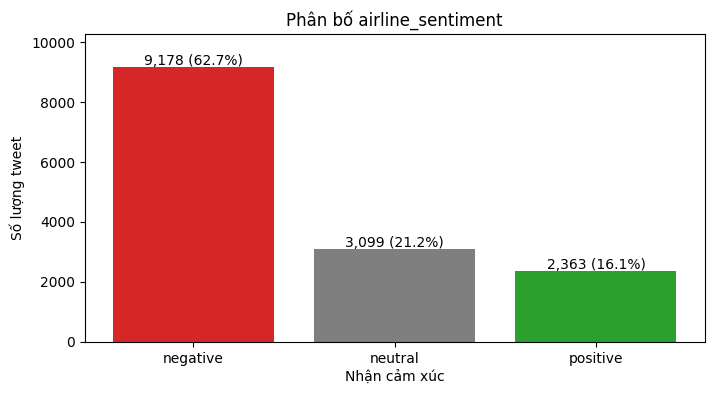

In [15]:
sentiment_order = ["negative", "neutral", "positive"]

# Phân bố nhãn sentiment
# Đếm số lượng mỗi nhãn, sắp xếp theo thứ tự mong muốn, sau đó chuyển thành DataFrame để dễ hiển thị và vẽ biểu đồ.
sentiment_counts = (
    df["airline_sentiment"]
    .value_counts()
    .reindex(sentiment_order)
    .rename_axis("sentiment")
    .reset_index(name="count")
)
# Tính tỷ lệ phần trăm cho mỗi sentiment
sentiment_counts["ratio"] = sentiment_counts["count"] / sentiment_counts["count"].sum()

# Hiển thị bảng phân bố sentiment
display(sentiment_counts)

# Vẽ biểu đồ cột phân bố sentiment
plt.figure(figsize=(8, 4))
bars = plt.bar(
    sentiment_counts["sentiment"],
    sentiment_counts["count"],
    color=["#d62728", "#7f7f7f", "#2ca02c"],
)
plt.title("Phân bố airline_sentiment")
plt.xlabel("Nhận cảm xúc")
plt.ylabel("Số lượng tweet")
for bar, count, ratio in zip(bars, sentiment_counts["count"], sentiment_counts["ratio"]):
    plt.text(bar.get_x() + bar.get_width() / 2, count + 60, f"{count:,} ({ratio:.1%})", ha="center")
plt.ylim(0, sentiment_counts["count"].max() * 1.12)
plt.show()


,airline,negativereason,count
0,US Airways,Customer Service Issue,811
1,American,Customer Service Issue,768
2,United,Customer Service Issue,681
5,Southwest,Customer Service Issue,391
8,Delta,Late Flight,269
35,Virgin America,Customer Service Issue,60


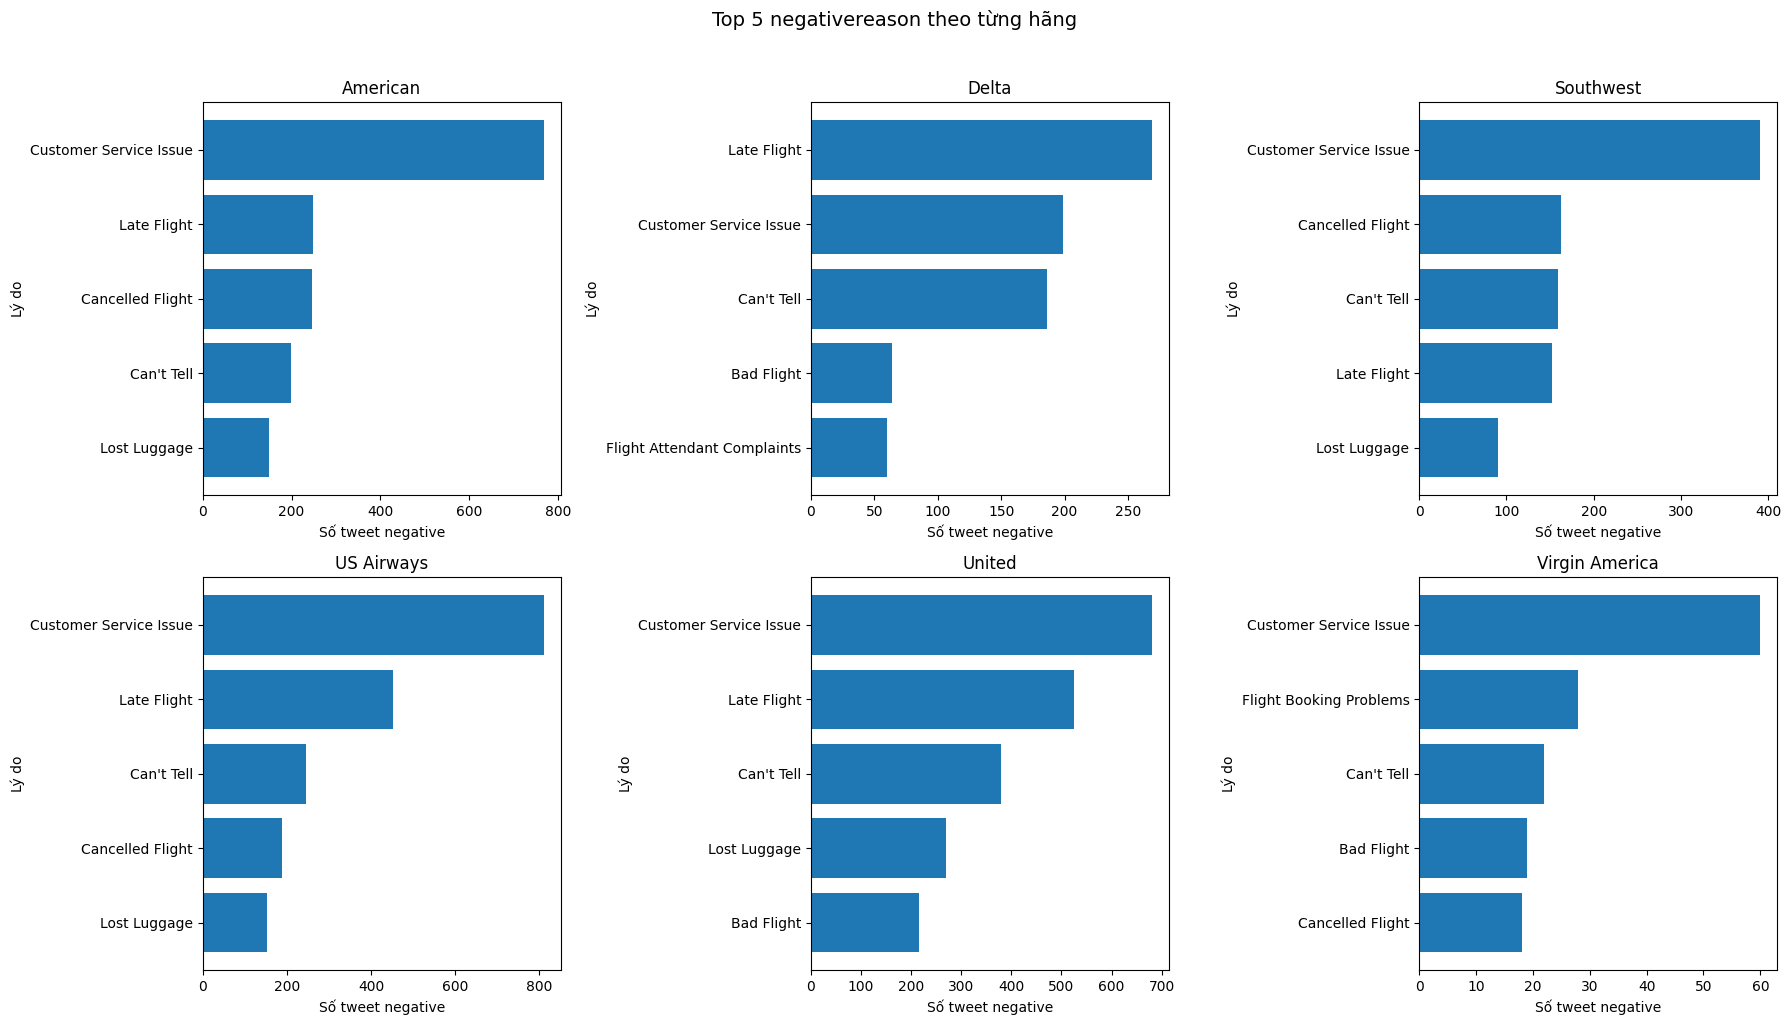

In [16]:
# Phân tích lý do negative phổ biến nhất theo từng hãng
# Đếm số lượng mỗi lý do negative theo từng hãng, sau đó chọn top 5 lý do phổ biến nhất cho mỗi hãng.
negative_reason_counts = (
    df.loc[
        df["airline_sentiment"].eq("negative") & df["negativereason"].notna(),
        ["airline", "negativereason"],
    ]
    .value_counts()
    .rename("count")
    .reset_index()
)

# Chọn top 5 lý do phổ biến nhất cho mỗi hãng
top_reason_per_airline = (
    negative_reason_counts
    .sort_values(["airline", "count"], ascending=[True, False])
    .groupby("airline", group_keys=False)
    .head(5)
)

# Hiển thị lý do negative phổ biến nhất theo từng hãng
most_common_reason = (
    top_reason_per_airline
    .groupby("airline", group_keys=False)
    .head(1)
    .sort_values("count", ascending=False)
)

# Hiển thị lý do negative phổ biến nhất theo từng hãng
display(most_common_reason)

# Vẽ biểu đồ cột ngang cho top 5 lý do negative phổ biến nhất theo từng hãng
airlines = sorted(top_reason_per_airline["airline"].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False)
axes = axes.flatten()

for ax, airline in zip(axes, airlines):
    subset = top_reason_per_airline[top_reason_per_airline["airline"] == airline].sort_values("count")
    ax.barh(subset["negativereason"], subset["count"], color="#1f77b4")
    ax.set_title(airline)
    ax.set_xlabel("Số tweet negative")
    ax.set_ylabel("Lý do")

for ax in axes[len(airlines):]:
    ax.axis("off")

plt.suptitle("Top 5 negativereason theo từng hãng", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### Vector hóa văn bản bằng TF-IDF

Sử dụng cột `text_preprocessed` đã làm sạch để tạo ma trận đặc trưng. Cấu hình `ngram_range=(1, 2)` giữ cả unigram và bigram


In [17]:
# Chuẩn bị dữ liệu cho mô hình hóa: chỉ giữ các dòng có text đã được tiền xử lý (loại bỏ dòng trống sau khi làm sạch).
text_series = df["text_preprocessed"].fillna("").astype(str)
non_empty_mask = text_series.str.strip().ne("")

# Tạo ma trận TF-IDF cho các dòng có text đã được tiền xử lý, đồng thời lấy nhãn sentiment tương ứng cho các dòng này.
X_text = text_series[non_empty_mask]
y = df.loc[non_empty_mask, "airline_sentiment"]

# Vector hóa TF-IDF với n-gram (1, 2) và chỉ giữ các từ xuất hiện ít nhất 2 lần trong tập dữ liệu để giảm nhiễu.
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(X_text)
feature_names = tfidf.get_feature_names_out()

print("Số dòng được vector hóa:", X_tfidf.shape[0])
print("Số đặc trưng TF-IDF:", X_tfidf.shape[1])
print("Kích thước ma trận:", X_tfidf.shape)
print("Ví dụ 20 đặc trưng đầu tiên:")
print(feature_names[:20])

tfidf_preview = pd.DataFrame(
    {
        "feature": feature_names[:15],
        "idf": tfidf.idf_[:15],
        "tf": X_tfidf[:, :15].toarray().sum(axis=0),
        "tf_idf": X_tfidf[:, :15].toarray().sum(axis=0) * tfidf.idf_[:15],
    }
)
display(tfidf_preview)


Số dòng được vector hóa: 14598
Số đặc trưng TF-IDF: 15889
Kích thước ma trận: (14598, 15889)
Ví dụ 20 đặc trưng đầu tiên:
['aa' 'aa agent' 'aa air' 'aa also' 'aa contact' 'aa customer' 'aa dallas'
 'aa dfw' 'aa direct' 'aa doesnt' 'aa email' 'aa employee' 'aa family'
 'aa flight' 'aa gate' 'aa go' 'aa gold' 'aa help' 'aa metal' 'aa mile']


,feature,idf,tf,tf_idf
0,aa,5.346961,41.911288,224.098033
1,aa agent,8.979270,1.366271,12.268119
2,aa air,9.490096,0.548201,5.202479
3,aa also,9.490096,0.652691,6.194103
4,aa contact,9.490096,0.721625,6.848288
5,aa customer,8.979270,1.173900,10.540763
6,aa dallas,9.490096,0.672133,6.378605
7,aa dfw,9.202414,0.756966,6.965911
8,aa direct,9.490096,0.581773,5.521086
9,aa doesnt,9.490096,0.461482,4.379513


## III. Huấn luyện và Đánh giá đa lớp
Phần này được chia thành 2 giai đoạn để so sánh tác động của mất cân bằng lớp:
1. Huấn luyện model trước khi xử lý mất cân bằng
2. Huấn luyện model sau khi xử lý mất cân bằng bằng `class_weight="balanced"`.

Metric chính là `Macro F1-Score`, kèm `classification_report` và `Confusion Matrix`.


In [18]:
# Chia tập dữ liệu thành train/test với tỷ lệ 80/20, đảm bảo phân bố nhãn được giữ nguyên (stratify).
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Vector hóa TF-IDF cho tập train và test, sử dụng cùng một bộ vectorizer đã fit trên toàn bộ dữ liệu để đảm bảo tính nhất quán của đặc trưng.
tfidf_cls = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf_cls.fit_transform(X_train_text)
X_test_tfidf = tfidf_cls.transform(X_test_text)

print("Train size:", X_train_tfidf.shape)
print("Test size:", X_test_tfidf.shape)
print("Train label distribution:")
display(y_train.value_counts(normalize=True).rename("ratio").reset_index(name="ratio"))


Train size: (11678, 12894)
Test size: (2920, 12894)
Train label distribution:


,airline_sentiment,ratio
0,negative,0.627933
1,neutral,0.210481
2,positive,0.161586


In [19]:
# Định nghĩa hàm đánh giá mô hình: huấn luyện mô hình, dự đoán trên tập test, tính macro F1-score và in báo cáo phân loại.
label_order = ["negative", "neutral", "positive"]

def evaluate_models(models, X_train, X_test, y_train, y_test, stage_name):
    rows = []
    predictions = {}
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        predictions[model_name] = y_pred
        rows.append({
            "stage": stage_name,
            "model": model_name,
            "macro_f1": f1_score(y_test, y_pred, average="macro"),
        })
        print(f"\n=== {stage_name} | {model_name} ===")
        print(classification_report(y_test, y_pred, digits=4))
    result_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
    return result_df, predictions


### A. Trước khi xử lý imbalance
Hai model có cấu hình cơ bản, chưa cân bằng trọng số giữa các lớp


In [20]:
models_before = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}

results_before, preds_before = evaluate_models(
    models_before,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Before imbalance handling",
)
display(results_before)



=== Before imbalance handling | Logistic Regression ===
              precision    recall  f1-score   support

    negative     0.7858    0.9367    0.8547      1833
     neutral     0.6535    0.4049    0.5000       615
    positive     0.7655    0.5742    0.6562       472

    accuracy                         0.7661      2920
   macro avg     0.7350    0.6386    0.6703      2920
weighted avg     0.7547    0.7661    0.7479      2920


=== Before imbalance handling | Random Forest ===
              precision    recall  f1-score   support

    negative     0.7927    0.9116    0.8480      1833
     neutral     0.6096    0.4520    0.5191       615
    positive     0.7107    0.5360    0.6111       472

    accuracy                         0.7541      2920
   macro avg     0.7043    0.6332    0.6594      2920
weighted avg     0.7409    0.7541    0.7405      2920



,stage,model,macro_f1
0,Before imbalance handling,Logistic Regression,0.670276
1,Before imbalance handling,Random Forest,0.659420


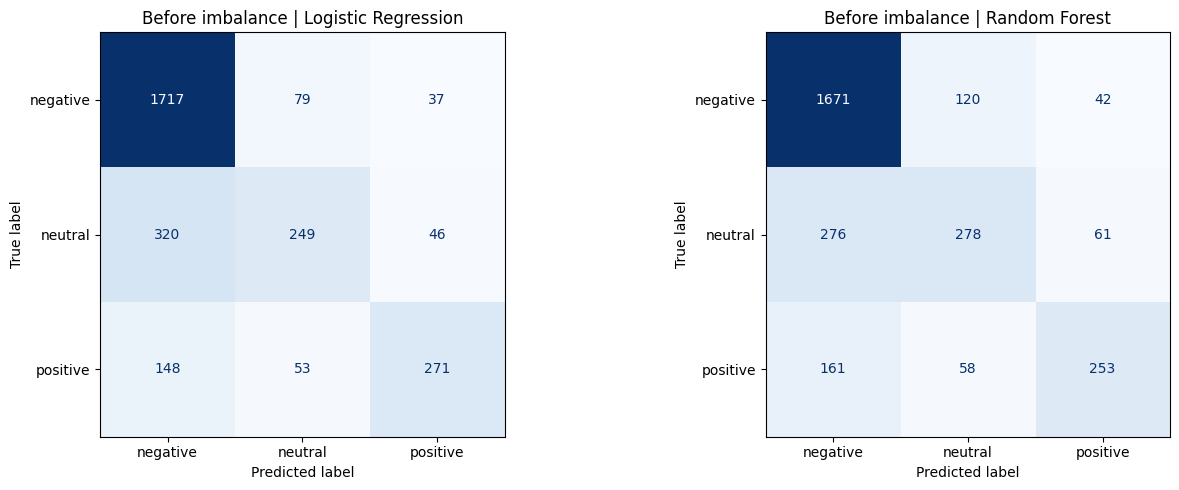

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model_name, y_pred) in zip(axes, preds_before.items()):
    cm = confusion_matrix(y_test, y_pred, labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Before imbalance | {model_name}")
plt.tight_layout()
plt.show()


### B. Sau khi xử lý imbalance

Sử dụng `class_weight="balanced"` để tăng trọng số cho các label ít hơn


In [22]:
models_after = {
    "Logistic Regression (balanced)": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    ),
    "Random Forest (balanced)": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"
    ),
}

results_after, preds_after = evaluate_models(
    models_after,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "After imbalance handling",
)
display(results_after)



=== After imbalance handling | Logistic Regression (balanced) ===
              precision    recall  f1-score   support

    negative     0.8845    0.8025    0.8415      1833
     neutral     0.5484    0.6537    0.5964       615
    positive     0.6546    0.7267    0.6888       472

    accuracy                         0.7589      2920
   macro avg     0.6959    0.7276    0.7089      2920
weighted avg     0.7766    0.7589    0.7652      2920


=== After imbalance handling | Random Forest (balanced) ===
              precision    recall  f1-score   support

    negative     0.8122    0.8942    0.8512      1833
     neutral     0.5981    0.5057    0.5480       615
    positive     0.6990    0.5657    0.6253       472

    accuracy                         0.7592      2920
   macro avg     0.7031    0.6552    0.6748      2920
weighted avg     0.7488    0.7592    0.7508      2920



,stage,model,macro_f1
0,After imbalance handling,Logistic Regression (balanced),0.708909
1,After imbalance handling,Random Forest (balanced),0.674839


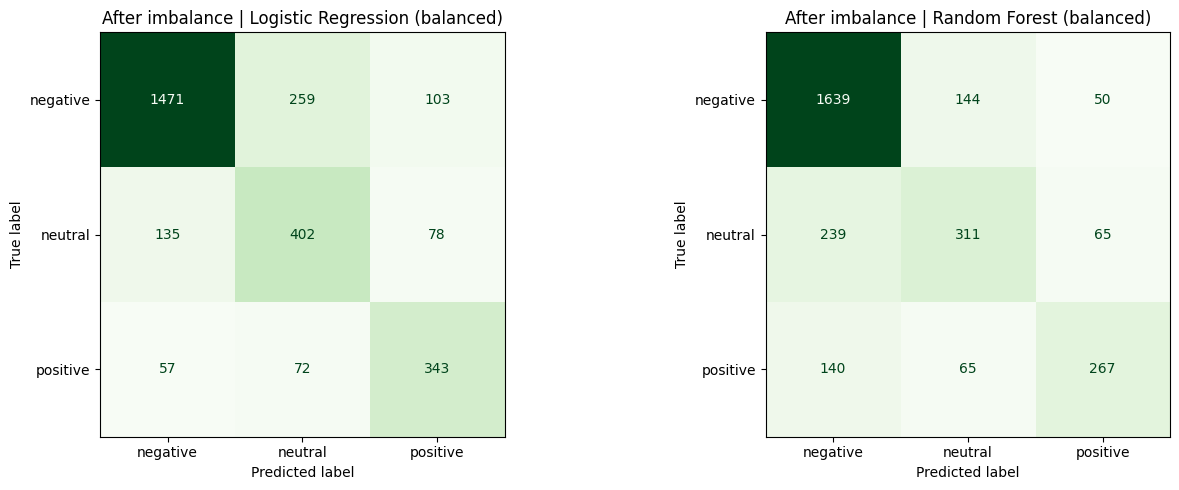

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model_name, y_pred) in zip(axes, preds_after.items()):
    cm = confusion_matrix(y_test, y_pred, labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(f"After imbalance | {model_name}")
plt.tight_layout()
plt.show()


In [24]:
comparison_df = pd.concat([results_before, results_after], ignore_index=True)
comparison_df = comparison_df.sort_values(["stage", "macro_f1"], ascending=[True, False])
display(comparison_df)


,stage,model,macro_f1
2,After imbalance handling,Logistic Regression (balanced),0.708909
3,After imbalance handling,Random Forest (balanced),0.674839
0,Before imbalance handling,Logistic Regression,0.670276
1,Before imbalance handling,Random Forest,0.659420


### III.2 Cai thien mo hinh

Phan nay thu nghiem them 4 huong xu ly imbalance tren Logistic Regression de cai thien Macro F1-Score:
1. Tang trong so rieng cho lop `negative`.
2. SMOTE.
3. ADASYN.
4. Random undersampling.

Tat ca phuong phap deu duoc train tren tap train va danh gia tren cung tap test da tach o tren de so sanh cong bang.


In [25]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

improve_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_train_imp = improve_vectorizer.fit_transform(X_train_text)
X_test_imp = improve_vectorizer.transform(X_test_text)

print("Original train distribution:")
display(y_train.value_counts().rename_axis("label").reset_index(name="count"))


Original train distribution:


,label,count
0,negative,7333
1,neutral,2458
2,positive,1887


In [26]:
improvement_rows = []
improvement_predictions = {}
improvement_reports = {}

def fit_eval_lr(name, X_train_used, y_train_used, model):
    model.fit(X_train_used, y_train_used)
    y_pred = model.predict(X_test_imp)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    improvement_rows.append({
        "method": name,
        "macro_f1": macro_f1,
        "train_size_after_sampling": len(y_train_used),
    })
    improvement_predictions[name] = y_pred
    improvement_reports[name] = classification_report(y_test, y_pred, digits=4)

# Baseline tham chieu
fit_eval_lr(
    "Baseline Logistic Regression",
    X_train_imp,
    y_train,
    LogisticRegression(max_iter=2000, random_state=42),
)

# Tang trong so cho lop negative
fit_eval_lr(
    "Penalty on negative (Logistic Regression)",
    X_train_imp,
    y_train,
    LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight={"negative": 2.0, "neutral": 1.0, "positive": 1.0},
    ),
)

# Tăng trọng số cho lớp negative trong Random Forest
fit_eval_lr(
    "Penalty on negative (Random Forest)",
    X_train_imp,
    y_train,
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight={"negative": 2.0, "neutral": 1.0, "positive": 1.0},
    ),
)

# SMOTE - SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imp, y_train)
fit_eval_lr(
    "SMOTE Logistic Regression",
    X_train_smote,
    y_train_smote,
    LogisticRegression(max_iter=2000, random_state=42),
)

# SMOTE - Logistic Regression với trọng số lớp
fit_eval_lr(
    "SMOTE (Logistic Regression + penalty)",
    X_train_smote,
    y_train_smote,
    LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight={"negative": 2.0, "neutral": 1.0, "positive": 1.0},
    ),
)

# SMOTE - Random Forest
fit_eval_lr(
    "SMOTE (Random Forest)",
    X_train_smote,
    y_train_smote,
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
)

# SMOTE - Random Forest với trọng số lớp
fit_eval_lr(
    "SMOTE (Random Forest + penalty)",
    X_train_smote,
    y_train_smote,
    RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight={"negative": 2.0, "neutral": 1.0, "positive": 1.0},
    ),
)

# ADASYN Logistic Regression
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_imp, y_train)
fit_eval_lr(
    "ADASYN Logistic Regression",
    X_train_adasyn,
    y_train_adasyn,
    LogisticRegression(max_iter=2000, random_state=42),
)

# ADASYN Random Forest
fit_eval_lr(
    "ADASYN Random Forest",
    X_train_adasyn,
    y_train_adasyn,
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
)

# Random undersampling (Logistic Regression)
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_imp, y_train)
fit_eval_lr(
    "Random undersampling (Logistic Regression)",
    X_train_under,
    y_train_under,
    LogisticRegression(max_iter=2000, random_state=42),
)

# Random undersampling (Random Forest)
fit_eval_lr(
    "Random undersampling (Random Forest)",
    X_train_under,
    y_train_under,
    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
)   

improvement_df = pd.DataFrame(improvement_rows).sort_values("macro_f1", ascending=False)
display(improvement_df)


,method,macro_f1,train_size_after_sampling
3,SMOTE Logistic Regression,0.696936,21999
7,ADASYN Logistic Regression,0.696415,21664
9,Random undersampling (Logistic Regression),0.685965,5661
8,ADASYN Random Forest,0.680613,21664
4,SMOTE (Logistic Regression + penalty),0.680060,21999
5,SMOTE (Random Forest),0.679405,21999
6,SMOTE (Random Forest + penalty),0.674562,21999
2,Penalty on negative (Random Forest),0.656580,11678
0,Baseline Logistic Regression,0.655535,11678
10,Random undersampling (Random Forest),0.631477,5661


In [27]:
# # Grid search cho Random forest và Logistic Regression với một số tham số khác nhau để tìm cấu hình tốt nhất.
# from sklearn.model_selection import GridSearchCV

# GRID_SEARCH_PARAMS = {
#     "Logistic Regression": {
#         "model": LogisticRegression(max_iter=2000, random_state=42),
#         "params": {
#             "class_weight": [None, "balanced", {"negative": 2.0, "neutral": 1.0, "positive": 1.0}],
#             "C": [0.01, 0.1, 1, 10],
#         },
#     },
#     "Random Forest": {
#         "model": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
#         "params": {
#             "class_weight": [None, "balanced", {"negative": 2.0, "neutral": 1.0, "positive": 1.0}],
#             "n_estimators": [100, 200, 300],
#             "max_depth": [None, 10, 20, 30],
#         },
#     },
# }

# # Thực hiện Grid Search
# grid_search_results = {}
# grid_search_predictions = {}
# grid_search_reports = {}

# for model_name, config in GRID_SEARCH_PARAMS.items():
#     print(f"\n{'='*60}")
#     print(f"Grid Search for {model_name}")
#     print(f"{'='*60}")
    
#     # Tạo GridSearchCV
#     grid_search = GridSearchCV(
#         estimator=config["model"],
#         param_grid=config["params"],
#         cv=5,
#         scoring='f1_macro',
#         n_jobs=-1,
#         verbose=2
#     )
    
#     # Fit model
#     print(f"\nTraining {model_name} with Grid Search...")
#     grid_search.fit(X_train_imp, y_train)
    
#     # Lưu best estimator
#     best_model = grid_search.best_estimator_
    
#     # Dự đoán
#     y_pred = best_model.predict(X_test_imp)
    
#     # Tính metrics
#     macro_f1 = f1_score(y_test, y_pred, average='macro')
#     report = classification_report(y_test, y_pred, target_names=label_order, output_dict=True)
    
#     # Lưu kết quả
#     grid_search_results[model_name] = {
#         "best_params": grid_search.best_params_,
#         "best_score": grid_search.best_score_,
#         "macro_f1": macro_f1,
#         "model": best_model
#     }
#     grid_search_predictions[model_name] = y_pred
#     grid_search_reports[model_name] = classification_report(y_test, y_pred, target_names=label_order)
    
#     # In kết quả
#     print(f"\n{model_name} - Best Parameters:")
#     for param, value in grid_search.best_params_.items():
#         print(f"  {param}: {value}")
#     print(f"\nBest CV Score (F1 Macro): {grid_search.best_score_:.4f}")
#     print(f"Test F1 Macro: {macro_f1:.4f}")
#     print(f"\nClassification Report:")
#     print(grid_search_reports[model_name])

# # Tổng kết kết quả
# print(f"\n{'='*60}")
# print("SUMMARY OF GRID SEARCH RESULTS")
# print(f"{'='*60}")
# for model_name, results in grid_search_results.items():
#     print(f"\n{model_name}:")
#     print(f"  Best CV F1 Macro: {results['best_score']:.4f}")
#     print(f"  Test F1 Macro: {results['macro_f1']:.4f}")

Best method: SMOTE Logistic Regression
              precision    recall  f1-score   support

    negative     0.8467    0.8587    0.8527      1833
     neutral     0.5630    0.5447    0.5537       615
    positive     0.6888    0.6801    0.6844       472

    accuracy                         0.7637      2920
   macro avg     0.6995    0.6945    0.6969      2920
weighted avg     0.7614    0.7637    0.7625      2920



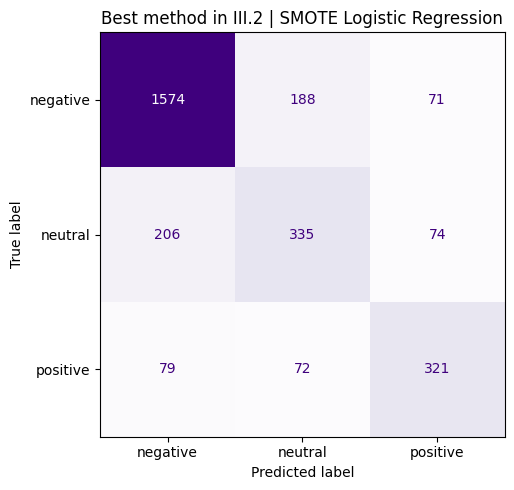

In [28]:
best_method = improvement_df.iloc[0]["method"]
print("Best method:", best_method)
print(improvement_reports[best_method])

cm = confusion_matrix(y_test, improvement_predictions[best_method], labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title(f"Best method in III.2 | {best_method}")
plt.tight_layout()
plt.show()


In [29]:
# Nhận xét cho III.2
